# MUBAC Intermediate Workshop

Welcome everyone! 👋

Before we get started, a quick intro —
**I am Amit, a second year PhD student at the Australian Astronomical Optics (AAO). Please reachout to me at [amit.deokar@mq.edu.au](mailto:amit.deokar@mq.edu.au), if you need me after this class**

---

In this session, we’re going to work with a real (and slightly messy) dataset of data science job listings. The idea is to experience what working with data actually feels like — not perfectly clean, not perfectly structured, but something we need to make sense of.

We’ll start by exploring the data using Pandas, then clean it up step by step — fixing inconsistencies, handling missing values, and combining datasets from different sources. Once we have something usable, we’ll look for patterns, check correlations, and build a simple linear regression model to understand trends.

By the end, you should have a solid feel for how raw data turns into insights — and more importantly, how to approach messy data without getting overwhelmed.

Let’s get started 🚀


To download this notebook and the associated data for this workshop, please go to - [github.com/amitvdeokar/mubac-intermediate-workshop](https://github.com/amitvdeokar/mubac-intermediate-workshop.git)

To run this notebook, you'll need [Python](https://www.python.org/downloads/release/python-3143/) installed on your computer and also something to read the notebook file like [Jupyter](https://jupyter.org/install) or [Visual Studio Code](https://code.visualstudio.com/download). You can also use [Google Colab](https://colab.research.google.com/). If you are working offline then use one of these installed softwares, to open the `.ipynb` file directly or upload the `.ipynb` file and the `csv` files to your google colab.

## Part 0 - Introduction to Loops

### The `for` and `while` loops

In Python, there are just two types of loops: `for` and `while`. `for` loops are useful for repeating a set of statements for each item in a collection (tuple, set, list, dictionary, or string). `while` loops are not as common, but can be used to repeat a set of statements until a boolean expression becomes false.

In [1]:
for i in [0, 1, 2, 3]:
    print(i)

0
1
2
3


The built-in function `range`, which returns a list of numbers, is often handy here:

In [2]:
for i in range(4):
    print(i)

0
1
2
3


Or you can have the range start from a nonzero value:

In [3]:
for i in range(-2, 4):
    print(i)

-2
-1
0
1
2
3


In [6]:
#Try - print squares of the first 4 digits
for i in range(4):
    print(i**2)

0
1
4
9


You can iterate over the keys and values in a dictionary with `.items()`:

In [7]:
d = {'foo': 3, 'bar': 5, 'bat': 9}
for key, val in d.items():
    print(key, '...', val)

foo ... 3
bar ... 5
bat ... 9


The syntax of the `while` loop is similar to the `if` statement:

In [8]:
a = 1
while a < 5:
    a = a * 2
    print(a)

2
4
8


In [9]:
# Try - print first 5 even numbers 
count = 0
n = 1
while count < 5:
    if n % 2 == 0:
        print(n)
        count += 1
    n += 1

2
4
6
8
10


## Part 1 - Hands-on with JOBS Data

You have received job listing data from **two different job agencies**:

- Agency Alpha
- Agency Beta

Lets inspect these datasets ...

### Pandas

To inspect and work with our data, we’ll use **Pandas** — one of the most important Python libraries for data analysis.

Pandas allows us to:
- Load data from files (like CSVs)
- View and explore datasets
- Clean and transform messy data
- Perform basic analysis

#### Basic Idea
Pandas works with a structure called a **DataFrame**.

Think of a DataFrame as:
> A table (like Excel), with rows and columns

In [10]:
#Import pandas and other packages
import pandas as pd #Data exploration and manipulation 
import numpy as np #Numerical operations
import matplotlib.pyplot as plt #Visualization/Plotting

In [11]:
#Load a CSV file using pandas
#Lets load data for Agency_A
df_agn_a = pd.read_csv('Uncleaned_Agency_A_DS_jobs.csv')

In [12]:
#Visually Inpsect it
#Lets look at the first 5 rows in our dataset
df_agn_a.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,experience_level
0,0,Data Scientist,137-171,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Other,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",2
1,1,Data Scientist,137-171,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),NaN,3
2,2,Data Scientist,137-171,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Company - Private,Consulting,Business Services,$100 to $500 million (USD),NaN,3
3,3,Data Scientist,137-171,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",3
4,4,Data Scientist,137-171,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",3


In [13]:
#We can similarly look at the last 5 rows
df_agn_a.tail()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,experience_level
310,310,Data Scientist,145-225,Job Description\nTitle: Data Scientist\nLocati...,4.4,Adwait Algorithm,"New York, NY","Houston, TX",51 to 200 employees,2015.0,Company - Private,IT Services,Information Technology,Unknown / Non-Applicable,NaN,3
311,311,Data Analyst,145-225,"Title: Health Plan Data Analyst, Sr\n\nCook Ch...",3.8,Cook Children's Health Care System,"Fort Worth, TX","Fort Worth, TX",5001 to 10000 employees,1918.0,Other,Health Care Services & Hospitals,Health Care,$100 to $500 million (USD),"Children's Health, Texas Health Resources, Bay...",3
312,312,Other,145-225,Rubius Therapeutics is a clinical-stage biopha...,3.8,Rubius Therapeutics,"Smithfield, RI","Cambridge, MA",201 to 500 employees,2013.0,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$100 to $500 million (USD),NaN,3
313,313,Data Scientist,145-225,Data Scientist\n\nJob Introduction\nFLEETCOR i...,3.5,Cambridge FX,"Atlanta, GA","Toronto, Canada",201 to 500 employees,1992.0,Company - Public,Financial Transaction Processing,Finance,$100 to $500 million (USD),NaN,3
314,314,Data Scientist,145-225,About Us\n\nOn the off chance you've thought a...,3.8,Metromile,"San Francisco, CA","San Francisco, CA",201 to 500 employees,2011.0,Company - Private,Insurance Carriers,Insurance,Unknown / Non-Applicable,NaN,3


In [14]:
#If you only want to get list of all your columns
df_agn_a.columns

Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'experience_level'],
      dtype='object')

In [15]:
#To infer the size of the dataset
df_agn_a.shape

(315, 16)

In [16]:
#To get the information on the dataset as a whole
df_agn_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              315 non-null    int64  
 1   Job Title          315 non-null    object 
 2   Salary Estimate    315 non-null    object 
 3   Job Description    315 non-null    object 
 4   Rating             309 non-null    float64
 5   Company Name       315 non-null    object 
 6   Location           315 non-null    object 
 7   Headquarters       312 non-null    object 
 8   Size               313 non-null    object 
 9   Founded            292 non-null    float64
 10  Type of ownership  312 non-null    object 
 11  Industry           299 non-null    object 
 12  Sector             299 non-null    object 
 13  Revenue            313 non-null    object 
 14  Competitors        94 non-null     object 
 15  experience_level   315 non-null    int64  
dtypes: float64(2), int64(2), o

Now lets try and look at the dataset from Agency_B

In [17]:
#Load data for Agency_A
df_agn_b = pd.read_csv('Uncleaned_Agency_B_DS_jobs.csv')

In [18]:
#Inspect the data and its column names
df_agn_b.head()

,index,job_title,salary,Job Description,company_rating,company,city,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,experience_level
0,315,Data Scientist,145-225,Who we are\nCriteo (NASDAQ: CRTO) is the globa...,3.9,Criteo,"Ann Arbor, MI","Paris, France",1001 to 5000 employees,2005.0,Company - Public,Internet,Information Technology,$2 to $5 billion (USD),"MediaMath, Conversant, AppNexus",3
1,316,Data Scientist,145-225,Job Description\nEssential Responsibilities:\n...,3.4,Advance Sourcing Concepts,"Pittsburgh, PA","Pittsburgh, PA",51 to 200 employees,NaN,Company - Private,NaN,NaN,$1 to $5 million (USD),NaN,3
2,317,Data Scientist,145-225,"Role - Data Scientist\nLoccation - NYC, NY\nPo...",3.8,Enterprise Solutions Inc,"New York, NY","Naperville, IL",51 to 200 employees,2000.0,Company - Private,Staffing & Outsourcing,Business Services,$25 to $50 million (USD),NaN,3
3,318,Data Analyst,145-225,Analytics - Business Assurance Data Analyst (C...,4.6,GreatAmerica Financial Services,"Cedar Rapids, IA","Cedar Rapids, IA",501 to 1000 employees,1992.0,Company - Private,Lending,Finance,$100 to $500 million (USD),NaN,3
4,319,Data Scientist,145-225,"Job Description\nSelecting features, building ...",NaN,Microagility,"New York, NY","Princeton, NJ",1 to 50 employees,NaN,Company - Private,Consulting,Business Services,$1 to $5 million (USD),NaN,2


In [19]:
df_agn_b.columns

Index(['index', 'job_title', 'salary', 'Job Description', 'company_rating',
       'company', 'city', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'experience_level'],
      dtype='object')

### Can we start analyzing these dataset?

No — not yet. The datasets need cleaning and standardization before reliable analysis.

### Agency Alpha
- Provides structured job listings
- Uses standard column names like:
  - Job Title
  - Salary Estimate
  - Company Name
  - Location
  - Rating

### Agency Beta
- Also provides job listings, but in a slightly different format
- Uses different column names such as:
  - job_title
  - salary
  - company
  - city
  - company_rating
  
*This is a very common real-world problem — data rarely comes clean or in a single format!*

Before you can analyze data or draw conclusions, you need a standardized dataset to start from.

To standardize the DS JOBS dataset, pick a common set of columns — use Agency Alpha's schema as the standard and modify Agency Beta's columns to match.

We'll use pandas' `.rename()` function to do this.

In [20]:
df_agn_b = df_agn_b.rename(columns={'job_title':'Job Title'})

In [21]:
#Lets check if it did what we wanted it to do
df_agn_b.head()

,index,Job Title,salary,Job Description,company_rating,company,city,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,experience_level
0,315,Data Scientist,145-225,Who we are\nCriteo (NASDAQ: CRTO) is the globa...,3.9,Criteo,"Ann Arbor, MI","Paris, France",1001 to 5000 employees,2005.0,Company - Public,Internet,Information Technology,$2 to $5 billion (USD),"MediaMath, Conversant, AppNexus",3
1,316,Data Scientist,145-225,Job Description\nEssential Responsibilities:\n...,3.4,Advance Sourcing Concepts,"Pittsburgh, PA","Pittsburgh, PA",51 to 200 employees,NaN,Company - Private,NaN,NaN,$1 to $5 million (USD),NaN,3
2,317,Data Scientist,145-225,"Role - Data Scientist\nLoccation - NYC, NY\nPo...",3.8,Enterprise Solutions Inc,"New York, NY","Naperville, IL",51 to 200 employees,2000.0,Company - Private,Staffing & Outsourcing,Business Services,$25 to $50 million (USD),NaN,3
3,318,Data Analyst,145-225,Analytics - Business Assurance Data Analyst (C...,4.6,GreatAmerica Financial Services,"Cedar Rapids, IA","Cedar Rapids, IA",501 to 1000 employees,1992.0,Company - Private,Lending,Finance,$100 to $500 million (USD),NaN,3
4,319,Data Scientist,145-225,"Job Description\nSelecting features, building ...",NaN,Microagility,"New York, NY","Princeton, NJ",1 to 50 employees,NaN,Company - Private,Consulting,Business Services,$1 to $5 million (USD),NaN,2


Find any columns that differ and rename them so they match Agency A's column names.

In [22]:
df_agn_b = df_agn_b.rename(columns={'salary':'Salary Estimate',
    'company':'Company Name',
    'city':'Location',
    'company_rating':'Rating'})

In [23]:
df_agn_b

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,experience_level
0,315,Data Scientist,145-225,Who we are\nCriteo (NASDAQ: CRTO) is the globa...,3.9,Criteo,"Ann Arbor, MI","Paris, France",1001 to 5000 employees,2005.0,Company - Public,Internet,Information Technology,$2 to $5 billion (USD),"MediaMath, Conversant, AppNexus",3
1,316,Data Scientist,145-225,Job Description\nEssential Responsibilities:\n...,3.4,Advance Sourcing Concepts,"Pittsburgh, PA","Pittsburgh, PA",51 to 200 employees,NaN,Company - Private,NaN,NaN,$1 to $5 million (USD),NaN,3
2,317,Data Scientist,145-225,"Role - Data Scientist\nLoccation - NYC, NY\nPo...",3.8,Enterprise Solutions Inc,"New York, NY","Naperville, IL",51 to 200 employees,2000.0,Company - Private,Staffing & Outsourcing,Business Services,$25 to $50 million (USD),NaN,3
3,318,Data Analyst,145-225,Analytics - Business Assurance Data Analyst (C...,4.6,GreatAmerica Financial Services,"Cedar Rapids, IA","Cedar Rapids, IA",501 to 1000 employees,1992.0,Company - Private,Lending,Finance,$100 to $500 million (USD),NaN,3
4,319,Data Scientist,145-225,"Job Description\nSelecting features, building ...",NaN,Microagility,"New York, NY","Princeton, NJ",1 to 50 employees,NaN,Company - Private,Consulting,Business Services,$1 to $5 million (USD),NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,667,Data Scientist,105-167,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,NaN,3
353,668,Data Scientist,105-167,Job Description\nBecome a thought leader withi...,NaN,JKGT,"San Francisco, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
354,669,Data Scientist,105-167,Join a thriving company that is changing the w...,NaN,AccessHope,"Irwindale, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
355,670,Data Scientist,105-167,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,NaN,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),NaN,3


#### Common data problems
- Inconsistent column names 
- Missing data 
- Outliers 
- Duplicate rows 
- Untidy 
- Need to process columns 
- Column types can signal unexpected data values


Even after matching column names, the datasets still have issues that block analysis — but with a shared schema we can merge them into one larger dataset and work from there.

### Combine Datasets

In [24]:
df = pd.concat([df_agn_a, df_agn_b], ignore_index=True)

In [25]:
df

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,experience_level
0,0,Data Scientist,137-171,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Other,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",2
1,1,Data Scientist,137-171,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),NaN,3
2,2,Data Scientist,137-171,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Company - Private,Consulting,Business Services,$100 to $500 million (USD),NaN,3
3,3,Data Scientist,137-171,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",3
4,4,Data Scientist,137-171,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,667,Data Scientist,105-167,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,NaN,3
668,668,Data Scientist,105-167,Job Description\nBecome a thought leader withi...,NaN,JKGT,"San Francisco, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
669,669,Data Scientist,105-167,Join a thriving company that is changing the w...,NaN,AccessHope,"Irwindale, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
670,670,Data Scientist,105-167,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,NaN,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),NaN,3


### Drop Reduntant Columns
First, remove unnecessary items, like redundant or non-useful columns from the dataset.

In [26]:
df = df.drop(columns=['index','Competitors','Job Description'])
df.head()

,Job Title,Salary Estimate,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,experience_level
0,Data Scientist,137-171,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Other,Insurance Carriers,Insurance,Unknown / Non-Applicable,2
1,Data Scientist,137-171,4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),3
2,Data Scientist,137-171,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Company - Private,Consulting,Business Services,$100 to $500 million (USD),3
3,Data Scientist,137-171,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),3
4,Data Scientist,137-171,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3


### Fix Missing Values
In pandas, `fillna()` fills NaNs with a chosen value or method; our dataset uses placeholders like `-1` or `Unknown` instead. First replace those placeholders with proper missing values or suitable defaults. Here we will replace them with NaNs and then simple drop incomplete or empty job records using `dropna()`

In [27]:
df = df.replace(['', ' ', -1, '-1'], np.nan)
df['Type of ownership'] = df['Type of ownership'].replace({'Unknown':np.nan})
df = df.dropna()
df

,Job Title,Salary Estimate,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,experience_level
0,Data Scientist,137-171,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Other,Insurance Carriers,Insurance,Unknown / Non-Applicable,2
1,Data Scientist,137-171,4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),3
2,Data Scientist,137-171,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Company - Private,Consulting,Business Services,$100 to $500 million (USD),3
3,Data Scientist,137-171,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),3
4,Data Scientist,137-171,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,Data Scientist,105-167,4.1,A-Line Staffing Solutions,"Durham, NC","Utica, MI",501 to 1000 employees,2004.0,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,3
665,Data Scientist,105-167,3.8,"Criterion Systems, Inc.","Vienna, VA","Vienna, VA",201 to 500 employees,2005.0,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),2
666,Data Scientist,105-167,4.0,Foundation Medicine,"Boston, MA","Cambridge, MA",1001 to 5000 employees,2010.0,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$100 to $500 million (USD),2
667,Data Scientist,105-167,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3


### Standardize Data Categories
When analyzing data, make sure each column is properly categorized.

For Job Title, lets restrict the values to:
- Data Scientist
- Data Analyst
- Data Engineer
- ML / AI
- Other

Use pandas' `unique()` to inspect the current job-title categories.

In [28]:
df['Job Title'].unique()

array(['Data Scientist', 'Other', 'Data Analyst', 'Data Engineer',
       'ML/AI', 'Data Engineer (Remote)', 'Business Data Analyst',
       'Data Scientist 3 (718)', 'Sr Data Analyst',
       'Principal Machine Learning Scientist',
       'Machine Learning Engineer/Scientist'], dtype=object)

You can also use `value_counts()`

In [29]:
df['Job Title'].value_counts(dropna=False)

Data Scientist                          348
Other                                    55
Data Engineer                            55
Data Analyst                             51
ML/AI                                    32
Data Scientist 3 (718)                    2
Principal Machine Learning Scientist      2
Machine Learning Engineer/Scientist       2
Data Engineer (Remote)                    1
Business Data Analyst                     1
Sr Data Analyst                           1
Name: Job Title, dtype: int64

To fix these issues we will use pandas function `replace()`

In [30]:
# Try it yourself 
df['Job Title'] = df['Job Title'].replace({'Data Scientist 3 (718)': 'Data Scientist',
                                          'Business Data Analyst': 'Data Analyst',
                                          'Sr Data Analyst': 'Data Analyst',
                                          'Data Engineer (Remote)': 'Data Engineer',
                                          'Principal Machine Learning Scientist': 'ML/AI',
                                          'Machine Learning Engineer/Scientist': 'ML/AI',
                                          })

### Reformat Data
Some fields are only useful after conversion to the right data type or structure. For example, Salary is stored as a string (object); convert it to numeric so it can be used in calculations.

In [31]:
#To make use of the salary estimate I want the minimum and maximum salary for the job
min_salary = []
max_salary = []

In [32]:
for val in df['Salary Estimate']:
    # Split into min and max
    parts = val.split('-')
    
    min_salary.append(int(parts[0]))
    max_salary.append(int(parts[1]))

In [33]:
# Assign to dataframe
df['min_salary'] = min_salary
df['max_salary'] = max_salary

In [34]:
# Drop original column
df = df.drop(columns=['Salary Estimate'])

In [35]:
df

,Job Title,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,experience_level,min_salary,max_salary
0,Data Scientist,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Other,Insurance Carriers,Insurance,Unknown / Non-Applicable,2,137,171
1,Data Scientist,4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),3,137,171
2,Data Scientist,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Company - Private,Consulting,Business Services,$100 to $500 million (USD),3,137,171
3,Data Scientist,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),3,137,171
4,Data Scientist,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3,137,171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,Data Scientist,4.1,A-Line Staffing Solutions,"Durham, NC","Utica, MI",501 to 1000 employees,2004.0,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,3,105,167
665,Data Scientist,3.8,"Criterion Systems, Inc.","Vienna, VA","Vienna, VA",201 to 500 employees,2005.0,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),2,105,167
666,Data Scientist,4.0,Foundation Medicine,"Boston, MA","Cambridge, MA",1001 to 5000 employees,2010.0,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$100 to $500 million (USD),2,105,167
667,Data Scientist,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3,105,167


There's more we could clean, but for this workshop we'll stop here — further cleaning depends on the analysis you plan to run.

## Part 2 - Data Exploraiton and Visualization

### What affects salary?

Given the above dataset, parameters that can potentially affect the salary are company rating, location, experience level, industry and company age.

Text(0, 0.5, 'Number of Jobs')

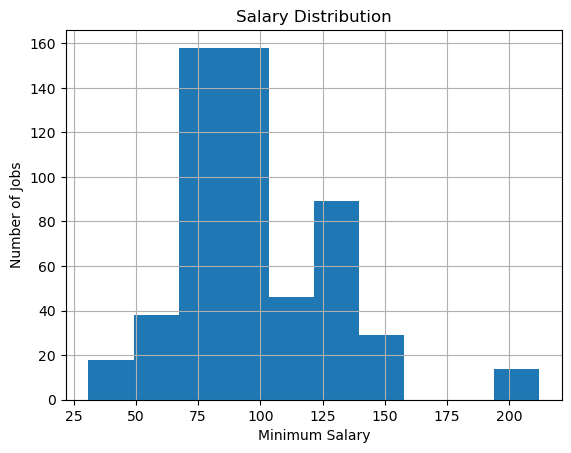

In [36]:
df['min_salary'].hist()
plt.title("Salary Distribution")
plt.xlabel("Minimum Salary")
plt.ylabel("Number of Jobs")

Now let’s examine how minimum salary relates to company age and rating.

In [37]:
#Compute Age of the company
df['Company Age'] = 2026 - df['Founded']

In [38]:
df

,Job Title,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,experience_level,min_salary,max_salary,Company Age
0,Data Scientist,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Other,Insurance Carriers,Insurance,Unknown / Non-Applicable,2,137,171,33.0
1,Data Scientist,4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),3,137,171,58.0
2,Data Scientist,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Company - Private,Consulting,Business Services,$100 to $500 million (USD),3,137,171,45.0
3,Data Scientist,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),3,137,171,26.0
4,Data Scientist,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3,137,171,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,Data Scientist,4.1,A-Line Staffing Solutions,"Durham, NC","Utica, MI",501 to 1000 employees,2004.0,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,3,105,167,22.0
665,Data Scientist,3.8,"Criterion Systems, Inc.","Vienna, VA","Vienna, VA",201 to 500 employees,2005.0,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),2,105,167,21.0
666,Data Scientist,4.0,Foundation Medicine,"Boston, MA","Cambridge, MA",1001 to 5000 employees,2010.0,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$100 to $500 million (USD),2,105,167,16.0
667,Data Scientist,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3,105,167,37.0


Text(0, 0.5, 'Min Salary')

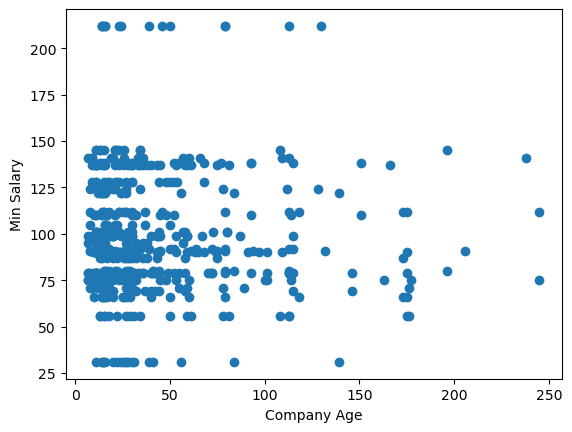

In [39]:
#Lets plot the Age vs minimum salary
plt.plot(df['Company Age'],df['min_salary'],'o')
plt.xlabel('Company Age')
plt.ylabel('Min Salary')

Text(0, 0.5, 'Min Salary')

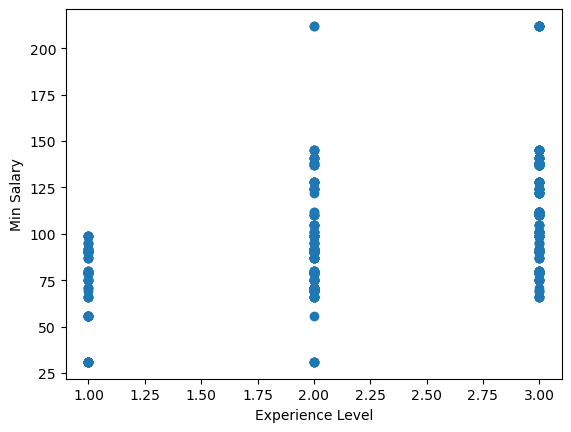

In [40]:
#Now plot the min_salary vs Company Age
plt.plot(df['experience_level'],df['min_salary'],'o')
plt.xlabel('Experience Level')
plt.ylabel('Min Salary')

We can check these relationships with pandas' `corr()` — it returns ~1 for strong positive correlation, ~0 for none, and negative for inverse correlation. Here the values show no clear correlation.

In [41]:
df[['min_salary', 'Company Age', 'experience_level']].corr()

,min_salary,Company Age,experience_level
min_salary,1.000000,0.001036,0.510582
Company Age,0.001036,1.000000,0.002145
experience_level,0.510582,0.002145,1.000000


We can also view what minimum salary in each sector looks like using the `groupby` function in pandas

In [42]:
df.groupby('Sector')['min_salary'].mean().sort_values()

Sector
Non-Profit                             31.000000
Construction, Repair & Maintenance     55.500000
Education                              74.000000
Agriculture & Forestry                 75.666667
Oil, Gas, Energy & Utilities           82.800000
Real Estate                            87.666667
Insurance                              88.781250
Telecommunications                     90.714286
Finance                                91.909091
Transportation & Logistics             92.333333
Information Technology                 95.113636
Biotech & Pharmaceuticals              97.428571
Health Care                            97.500000
Manufacturing                         100.956522
Aerospace & Defense                   101.823529
Business Services                     104.583333
Media                                 105.000000
Travel & Tourism                      106.333333
Government                            108.529412
Retail                                118.600000
Name: min_sal

<Axes: xlabel='Sector'>

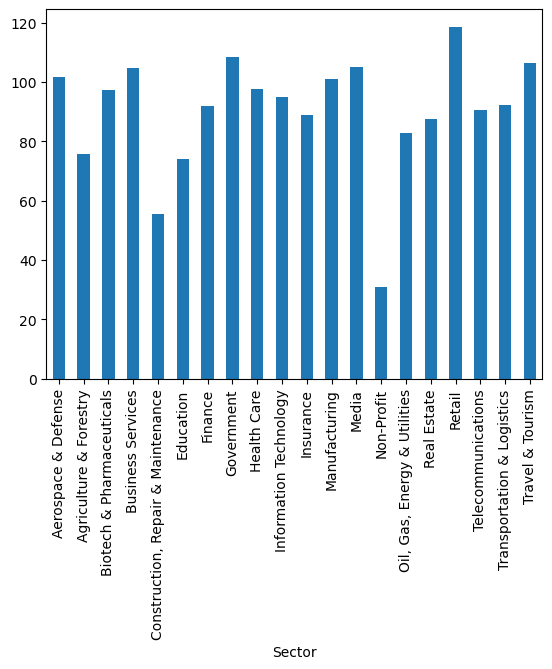

In [43]:
#Lets visualize the same using pandas inbuilt plotting utility 
df.groupby('Sector')['min_salary'].mean().plot(kind='bar')

## Part 3 - Modelling (Linear Regression)

Lets look at the interesting relationship between `Minimum Salary` and `Experience level` in detail.

In [44]:
df.groupby('experience_level')['min_salary'].mean()

experience_level
1     70.958763
2     90.991189
3    115.141593
Name: min_salary, dtype: float64

### Fit a linear model

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
X = df[['experience_level']]
y = df['min_salary']

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
print("Slope (coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (coefficient): 22.465887000105578
Intercept: 47.18077250340044


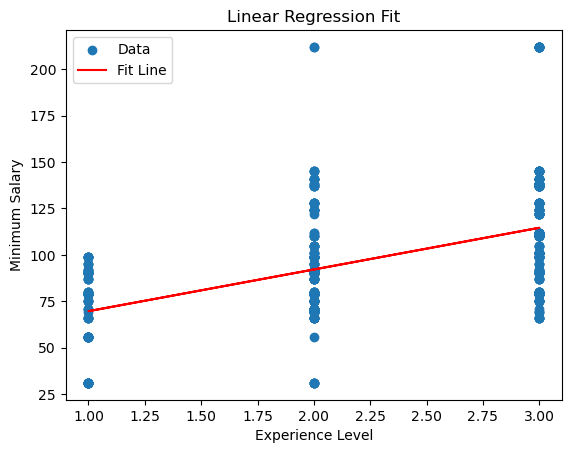

In [48]:
# Scatter plot
plt.scatter(df['experience_level'], df['min_salary'], label='Data')

# Create line for regression
x_vals = np.array(df['experience_level'])
y_vals = model.intercept_ + model.coef_[0] * x_vals

plt.plot(x_vals, y_vals, color='red', label='Fit Line')

plt.xlabel("Experience Level")
plt.ylabel("Minimum Salary")
plt.title("Linear Regression Fit")

plt.legend()
plt.show()

### Using this model, lets predict something
Predict salary for Mid-level (2)

In [49]:
model.predict([[2]])

/home/amit/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92.1125465])